In [14]:
# Observations stats 2.1 to 2.3

In [15]:
from __future__ import annotations
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np

# -----------------------
# Paths / Inputs
# -----------------------
ROOT = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026")
MAIN_CSV = ROOT / "5_Total_Repo.csv"

# Cutoff used in paper
CUTOFF_ISO = "2025-08-10 23:59:59+00:00"

# Output folder
OUT_DIR = ROOT / "RQ2_Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------
# Canonical labels
# -----------------------
THIRD = "Third-party device lab"
STATE_ORDER = ["Community", "Custom", "Mixed", "GMD", THIRD]

CI_COLS = {
    "GitHub Actions": "github_actions",
    "Travis CI": "travis_ci",
    "CircleCI": "circle_ci",
    "GitLab CI": "gitlab",
}

# -----------------------
# Helpers
# -----------------------
def parse_dt(x) -> pd.Timestamp:
    if x is None:
        return pd.NaT
    s = str(x).strip()
    if not s:
        return pd.NaT
    s = s.replace("Z", "+00:00")
    return pd.to_datetime(s, utc=True, errors="coerce")

def normalize_style_token(tok: str) -> str:
    t = str(tok).strip()
    if not t:
        return ""
    low = t.lower()

    if low in {"community", "emu_community"}:
        return "Community"
    if low in {"custom", "emu_custom"}:
        return "Custom"
    if low in {"gmd", "emu_gmd"}:
        return "GMD"
    if low == "mixed":
        return "Mixed"
    if "third" in low:              # catches ThirdParty / third-party / etc.
        return THIRD
    return t

def parse_style_set(cell) -> list[str]:
    if cell is None:
        return []
    s = str(cell).strip()
    if not s:
        return []

    s2 = s.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    seps = ["||", "+", ",", ";"]

    parts = [s2]
    for sep in seps:
        if sep in s2:
            parts = [p.strip() for p in s2.split(sep)]
            break

    toks = [normalize_style_token(p) for p in parts]
    toks = [t for t in toks if t and t != "Mixed"]  # Mixed is derived
    return sorted(set(toks))

def state_from_style_set(styles: list[str]) -> str:
    styles = [normalize_style_token(s) for s in styles if s]
    styles = sorted(set(styles))
    styles = [s for s in styles if s in {"Community", "Custom", "GMD", THIRD}]
    if not styles:
        return ""
    if len(styles) >= 2:
        return "Mixed"
    return styles[0]

def find_episode_csv(root: Path) -> Path:
    # prefer exact file if present
    p = root / "List_Change_Episodes.csv"
    if p.exists():
        return p

    candidates = []
    for name in ["List_Change_Episodes.csv", "list_of_episodes.csv"]:
        candidates += list(root.rglob(name))
    if not candidates:
        raise FileNotFoundError(
            f"Could not find episode CSV under {root}. "
            f"Expected List_Change_Episodes.csv or list_of_episodes.csv"
        )
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

def find_col(df: pd.DataFrame, options: list[str]) -> str | None:
    """Exact match first, then substring match."""
    cols = list(df.columns)
    lowmap = {c.lower(): c for c in cols}

    for o in options:
        k = o.lower()
        if k in lowmap:
            return lowmap[k]

    def score(colname: str, needle: str) -> float:
        c = colname.lower()
        n = needle.lower()
        sc = 0.0
        if c.startswith(n): sc += 100
        if c.endswith(n): sc += 50
        if n in c: sc += 10
        sc -= len(c) / 100.0
        return sc

    best, best_sc = None, -1e9
    for o in options:
        for c in cols:
            if o.lower() in c.lower():
                sc = score(c, o)
                if sc > best_sc:
                    best_sc, best = sc, c
    return best

def to_bool01(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()
    return s.isin({"1", "true", "yes", "y", "t"}).astype(int)

def save_df(df: pd.DataFrame, name: str) -> None:
    df.to_csv(OUT_DIR / name, index=False, encoding="utf-8")


In [16]:
EP_CSV = find_episode_csv(ROOT)
print(f"[info] Using episode CSV: {EP_CSV}")

ep = pd.read_csv(EP_CSV, dtype=str, keep_default_na=False, encoding="utf-8").copy()

# Identify key columns
col_repo  = find_col(ep, ["repo_name", "repo", "repository", "full_name"])
col_full  = find_col(ep, ["full_name", "repo_full_name"])
col_idx   = find_col(ep, ["episode_index", "episode_id", "idx"])
col_sutc  = find_col(ep, ["episode_start_utc", "start_utc", "start"])
col_eutc  = find_col(ep, ["episode_end_utc", "end_utc", "end"])
col_styleset = find_col(ep, ["episode_styleset", "styleset", "env_styles", "episode_styles", "env_style_set"])
col_state    = find_col(ep, ["episode_state_label", "episode_state", "state", "episode_state"])
col_active   = find_col(ep, ["is_active_at_cutoff", "active_at_cutoff", "is_active"])

print("[info] Detected columns:")
print("  repo:", col_repo)
print("  full:", col_full)
print("  idx :", col_idx)
print("  start:", col_sutc)
print("  end  :", col_eutc)
print("  styleset:", col_styleset)
print("  state   :", col_state)
print("  active  :", col_active)

if col_repo is None:
    raise ValueError("Could not find repo identifier column in episode CSV.")
if col_sutc is None or col_eutc is None:
    raise ValueError("Need episode_start_utc and episode_end_utc (or equivalents) in episode CSV.")
if col_styleset is None and col_state is None:
    raise ValueError("Could not find episode state/styleset column (episode_state_label / episode_styleset / etc.).")

# Parse times
ep["_start"] = ep[col_sutc].apply(parse_dt)
ep["_end"]   = ep[col_eutc].apply(parse_dt)

# Parse styles + state
if col_styleset is not None:
    ep["_styles"] = ep[col_styleset].apply(parse_style_set)
else:
    ep["_styles"] = [[] for _ in range(len(ep))]

if col_state is not None:
    ep["_state"] = ep[col_state].apply(normalize_style_token)
else:
    ep["_state"] = ep["_styles"].apply(state_from_style_set)

# Keep only canonical RQ2 states
ep = ep[ep["_state"].isin(STATE_ORDER)].copy()

# Episode ordering
if col_idx is not None:
    ep["_idx"] = pd.to_numeric(ep[col_idx], errors="coerce")
else:
    ep["_idx"] = pd.NaT
    print("[warn] No episode_index column found; will order episodes by start timestamp.")

# Common variables
cutoff = pd.to_datetime(CUTOFF_ISO, utc=True)

repos = sorted(ep[col_repo].unique().tolist())
N_REPOS = len(repos)
N_EPISODES = len(ep)

# transitions: consecutive episodes per repo
transitions = []
for r, sub in ep.groupby(col_repo, sort=False):
    sub = sub.sort_values(["_idx", "_start"] if col_idx else ["_start"])
    states = sub["_state"].tolist()
    for a, b in zip(states, states[1:]):
        transitions.append((a, b))
N_TRANSITIONS = len(transitions)

print("\n=== Scope (RQ2) ===")
print(f"Repos with >=1 canonical state: {N_REPOS}")
print(f"Retained episodes (rows): {N_EPISODES}")
print(f"Episode-to-episode transitions: {N_TRANSITIONS}")

save_df(pd.DataFrame([{
    "repos": N_REPOS,
    "retained_episodes": N_EPISODES,
    "transitions": N_TRANSITIONS,
    "episode_csv_used": str(EP_CSV),
}]), "rq2_scope_summary.csv")


[info] Using episode CSV: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations\List_Change_Episodes.csv
[info] Detected columns:
  repo: repo_name
  full: full_name
  idx : episode_index
  start: episode_start_utc
  end  : episode_end_utc
  styleset: episode_styleset
  state   : episode_state_label
  active  : is_active_at_cutoff

=== Scope (RQ2) ===
Repos with >=1 canonical state: 270
Retained episodes (rows): 320
Episode-to-episode transitions: 50


In [17]:
#observation 2.1

In [18]:
entry_state = {}
current_state = {}

for r, sub in ep.groupby(col_repo, sort=False):
    sub = sub.sort_values(["_idx", "_start"] if col_idx else ["_start"])
    entry_state[r] = sub.iloc[0]["_state"]

    # Current episode at cutoff:
    # Prefer explicit active flag; else use time containment.
    if col_active is not None:
        active = sub[to_bool01(sub[col_active]) == 1]
    else:
        active = sub[(sub["_start"] <= cutoff) & (sub["_end"] >= cutoff)]

    if len(active) > 0:
        active = active.sort_values(["_start"])
        current_state[r] = active.iloc[-1]["_state"]
    else:
        sub2 = sub.sort_values(["_end", "_start"])
        current_state[r] = sub2.iloc[-1]["_state"]

def dist_table(state_map: dict) -> pd.DataFrame:
    cnt = Counter(state_map.values())
    rows = []
    for st in STATE_ORDER:
        c = int(cnt.get(st, 0))
        rows.append({"State": st, "Count": c, "Percent": (100.0 * c / max(1, N_REPOS))})
    return pd.DataFrame(rows)

entry_df = dist_table(entry_state)
current_df = dist_table(current_state)
entry_current = entry_df.merge(current_df, on="State", suffixes=("_Entry", "_Current"))

print(entry_current.round(1).to_string(index=False))
save_df(entry_current, "rq2_entry_vs_current.csv")


                 State  Count_Entry  Percent_Entry  Count_Current  Percent_Current
             Community          114           42.2            137             50.7
                Custom          133           49.3            101             37.4
                 Mixed            7            2.6             12              4.4
                   GMD            4            1.5              6              2.2
Third-party device lab           12            4.4             14              5.2


In [19]:
edge_counts = Counter(transitions)

edge_rows = []
for (a, b), c in edge_counts.most_common():
    edge_rows.append({
        "From": a,
        "To": b,
        "Transition": f"{a} -> {b}",
        "Count": int(c),
        "Percent_of_all_transitions": (100.0 * c / max(1, N_TRANSITIONS))
    })

edges_df = pd.DataFrame(edge_rows)

print(edges_df.head(25).round(1).to_string(index=False))
save_df(edges_df, "rq2_transition_counts.csv")


                  From                     To                          Transition  Count  Percent_of_all_transitions
                Custom              Community                 Custom -> Community     29                        58.0
             Community                  Mixed                  Community -> Mixed      7                        14.0
                 Mixed              Community                  Mixed -> Community      3                         6.0
                Custom Third-party device lab    Custom -> Third-party device lab      2                         4.0
                Custom                    GMD                       Custom -> GMD      1                         2.0
             Community                    GMD                    Community -> GMD      1                         2.0
Third-party device lab                    GMD       Third-party device lab -> GMD      1                         2.0
                 Mixed                 Custom                   

In [20]:
if not MAIN_CSV.exists():
    print(f"[warn] MAIN_CSV not found: {MAIN_CSV}")
else:
    main = pd.read_csv(MAIN_CSV, dtype=str, keep_default_na=False, encoding="utf-8").copy()

    if "full_name" not in main.columns:
        raise ValueError("Main CSV must contain full_name for reliable CI coupling merge.")

    # Normalize join keys (case-insensitive)
    main["_full_key"] = main["full_name"].astype(str).str.strip().str.lower()

    # Prepare CI columns
    for nice, c in CI_COLS.items():
        if c in main.columns:
            main[c] = to_bool01(main[c])
        else:
            main[c] = 0

    # Determine active episodes at cutoff
    if col_active is not None:
        active_rows = ep[to_bool01(ep[col_active]) == 1].copy()
    else:
        active_rows = ep[(ep["_start"] <= cutoff) & (ep["_end"] >= cutoff)].copy()

    if col_full is None:
        raise ValueError("Episode CSV must contain full_name (or equivalent) for CI coupling.")

    active_rows["_full_key"] = active_rows[col_full].astype(str).str.strip().str.lower()

    current_tbl = (
        active_rows[["_full_key", "_state"]]
        .drop_duplicates("_full_key")
        .rename(columns={"_state": "current_state"})
    )

    m = current_tbl.merge(
        main[["_full_key"] + list(CI_COLS.values())],
        on="_full_key",
        how="left"
    )

    rows = []
    for st in STATE_ORDER:
        sub = m[m["current_state"] == st]
        n = len(sub)
        if n == 0:
            continue
        row = {"current_state": st, "n_repos": n}
        for nice, c in CI_COLS.items():
            row[f"{nice}_pct"] = 100.0 * float(sub[c].sum()) / n
        rows.append(row)

    coupling = pd.DataFrame(rows)
    print(coupling.round(1).to_string(index=False))
    save_df(coupling, "rq2_ci_coupling_at_cutoff.csv")


         current_state  n_repos  GitHub Actions_pct  Travis CI_pct  CircleCI_pct  GitLab CI_pct
             Community      137                29.2            1.5           2.9            0.0
                Custom      101                 5.0           84.2          14.9            3.0
                 Mixed       12                 8.3            8.3           0.0            8.3
                   GMD        6                 0.0            0.0           0.0           16.7
Third-party device lab       14                 0.0            7.1          50.0            0.0


In [21]:
#observation 2.2

In [22]:
episodes_per_repo = ep.groupby(col_repo).size()
n_one = int((episodes_per_repo == 1).sum())
n_multi = int((episodes_per_repo >= 2).sum())
max_eps = int(episodes_per_repo.max()) if len(episodes_per_repo) else 0

summary = pd.DataFrame([{
    "repos_total": N_REPOS,
    "repos_one_episode": n_one,
    "repos_multi_episode": n_multi,
    "max_episodes_per_repo": max_eps,
}])

print(summary.to_string(index=False))
save_df(summary, "rq2_stability_summary.csv")


 repos_total  repos_one_episode  repos_multi_episode  max_episodes_per_repo
         270                225                   45                      4


In [23]:
custom_to_comm_years = []

for r, sub in ep.groupby(col_repo, sort=False):
    sub = sub.sort_values(["_idx", "_start"] if col_idx else ["_start"]).reset_index(drop=True)
    for i in range(len(sub) - 1):
        a = sub.loc[i, "_state"]
        b = sub.loc[i+1, "_state"]
        if a == "Custom" and b == "Community":
            dt = sub.loc[i+1, "_start"]
            if pd.notna(dt):
                custom_to_comm_years.append(int(dt.year))

year_counts = Counter(custom_to_comm_years)
year_df = pd.DataFrame([{"year": y, "count": c} for y, c in sorted(year_counts.items())])

total_c2c = int(sum(year_counts.values()))
in_2020_2022 = int(sum(c for y, c in year_counts.items() if 2020 <= y <= 2022))
pct_2020_2022 = 100.0 * in_2020_2022 / max(1, total_c2c)

print(f"Total Custom->Community transitions: {total_c2c}")
print(f"Transitions starting in 2020–2022: {in_2020_2022}/{total_c2c} ({pct_2020_2022:.1f}%)")
print(year_df.to_string(index=False))

save_df(year_df, "rq2_custom_to_community_by_year.csv")


Total Custom->Community transitions: 29
Transitions starting in 2020–2022: 21/29 (72.4%)
 year  count
 2019      2
 2020      8
 2021      6
 2022      7
 2023      3
 2024      3


In [24]:
#observation 2.3

In [25]:
# Mixed at cutoff (repo-level)
mixed_at_cutoff = sum(1 for r in repos if current_state.get(r) == "Mixed")
print(f"Repos currently Mixed: {mixed_at_cutoff}/{N_REPOS} ({100.0*mixed_at_cutoff/max(1,N_REPOS):.1f}%)")

# Mixed episodes (episode-level)
mixed_eps = ep[ep["_state"] == "Mixed"].copy()
n_mixed_eps = len(mixed_eps)
print(f"Mixed episodes: {n_mixed_eps}/{N_EPISODES} ({100.0*n_mixed_eps/max(1,N_EPISODES):.1f}%)")

def combo_key(styles: list[str]) -> str:
    atoms = [s for s in styles if s in {"Community", "Custom", "GMD", THIRD}]
    atoms = sorted(set(atoms))
    return "+".join(atoms)

mixed_eps["combo"] = mixed_eps["_styles"].apply(combo_key)
combo_df = mixed_eps["combo"].value_counts(dropna=False).reset_index()
combo_df.columns = ["mixed_combo", "count"]
combo_df["percent_of_mixed_episodes"] = 100.0 * combo_df["count"] / max(1, n_mixed_eps)

print("\nMixed composition:")
print(combo_df.round(1).to_string(index=False))
save_df(combo_df, "rq2_mixed_composition.csv")

# Mixed as waypoint: transitions involving Mixed
edge_counts = Counter(transitions)
c_to_m = int(edge_counts.get(("Community", "Mixed"), 0))
m_to_c = int(edge_counts.get(("Mixed", "Community"), 0))

waypoint = pd.DataFrame([{
    "repos_total": N_REPOS,
    "mixed_at_cutoff_repos": mixed_at_cutoff,
    "mixed_episodes": n_mixed_eps,
    "community_to_mixed": c_to_m,
    "mixed_to_community": m_to_c,
}])

print("\nMixed waypoint summary:")
print(waypoint.to_string(index=False))
save_df(waypoint, "rq2_mixed_waypoint_summary.csv")


Repos currently Mixed: 12/270 (4.4%)
Mixed episodes: 17/320 (5.3%)

Mixed composition:
                     mixed_combo  count  percent_of_mixed_episodes
                Community+Custom      9                       52.9
                   Community+GMD      7                       41.2
Community+Third-party device lab      1                        5.9

Mixed waypoint summary:
 repos_total  mixed_at_cutoff_repos  mixed_episodes  community_to_mixed  mixed_to_community
         270                     12              17                   7                   3


In [ ]:
#state Machine

In [26]:
from pathlib import Path
from collections import Counter, defaultdict
import pandas as pd

# ---- RQ2 Observations folder (your location) ----
OBS_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations")

# Prefer this exact file; otherwise search the folder for it.
EPISODE_CSV = OBS_DIR / "List_Change_Episodes.csv"
if not EPISODE_CSV.exists():
    hits = list(OBS_DIR.rglob("List_Change_Episodes.csv"))
    if not hits:
        raise FileNotFoundError(f"Could not find List_Change_Episodes.csv under: {OBS_DIR}")
    hits.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    EPISODE_CSV = hits[0]

print("[info] Using:", EPISODE_CSV)

# ---- Load ----
ep = pd.read_csv(EPISODE_CSV, dtype=str, keep_default_na=False)

# Required columns in your file
# (your uploaded file uses: full_name, episode_index, episode_state_label)
repo_col  = "full_name" if "full_name" in ep.columns else "repo_name"
idx_col   = "episode_index" if "episode_index" in ep.columns else None
state_col = "episode_state_label" if "episode_state_label" in ep.columns else None

if state_col is None:
    raise ValueError("episode_state_label column not found in episode CSV.")

# Canonical node labels you asked for
NODES = ["Custom", "Community", "GMD", "ThirdParty", "Mixed"]

# keep only these states (and normalize trivial whitespace)
ep[state_col] = ep[state_col].astype(str).str.strip()
ep = ep[ep[state_col].isin(NODES)].copy()

# sort episodes within each repo
if idx_col is not None:
    ep["_idx"] = pd.to_numeric(ep[idx_col], errors="coerce")
    sort_cols = ["_idx"]
else:
    # fallback if no index column exists
    sort_cols = ["episode_start_utc"] if "episode_start_utc" in ep.columns else [state_col]

# ---- Build transitions across consecutive episodes per repo ----
transitions = []
for repo, sub in ep.groupby(repo_col, sort=False):
    sub = sub.sort_values(sort_cols)
    states = sub[state_col].tolist()
    for a, b in zip(states, states[1:]):
        if a != b:
            transitions.append((a, b))

edge_counts = Counter(transitions)
out_totals = Counter([a for a, b in transitions])

print("[info] total transitions:", len(transitions))
print("[info] outgoing totals:", dict(out_totals))

# ---- Compute TOP2 per source state: (target, prob, count) ----
TOP2 = {}
for src in NODES:
    total_out = out_totals.get(src, 0)
    if total_out == 0:
        TOP2[src] = []
        continue

    candidates = []
    for (a, b), c in edge_counts.items():
        if a == src:
            p = c / total_out
            candidates.append((b, float(p), int(c)))

    candidates.sort(key=lambda x: (-x[1], -x[2], x[0]))
    TOP2[src] = candidates[:2]

# Show what will be drawn
rows = []
for src, edges in TOP2.items():
    for rank, (tgt, p, n) in enumerate(edges, start=1):
        rows.append({"src": src, "rank": rank, "tgt": tgt, "p": p, "n": n, "total_out": out_totals.get(src, 0)})
top2_df = pd.DataFrame(rows)
print("\n[TOP2 edges that will be drawn]")
display(top2_df if len(top2_df) else pd.DataFrame(columns=["src","rank","tgt","p","n","total_out"]))


[info] Using: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\2 - RQ2\Observations\List_Change_Episodes.csv
[info] total transitions: 50
[info] outgoing totals: {'Custom': 33, 'Community': 9, 'Mixed': 5, 'ThirdParty': 2, 'GMD': 1}

[TOP2 edges that will be drawn]


,src,rank,tgt,p,n,total_out
0,Custom,1,Community,0.878788,29,33
1,Custom,2,ThirdParty,0.060606,2,33
2,Community,1,Mixed,0.777778,7,9
3,Community,2,GMD,0.111111,1,9
4,GMD,1,Mixed,1.000000,1,1
5,ThirdParty,1,GMD,0.500000,1,2
6,ThirdParty,2,Mixed,0.500000,1,2
7,Mixed,1,Community,0.600000,3,5
8,Mixed,2,Custom,0.200000,1,5


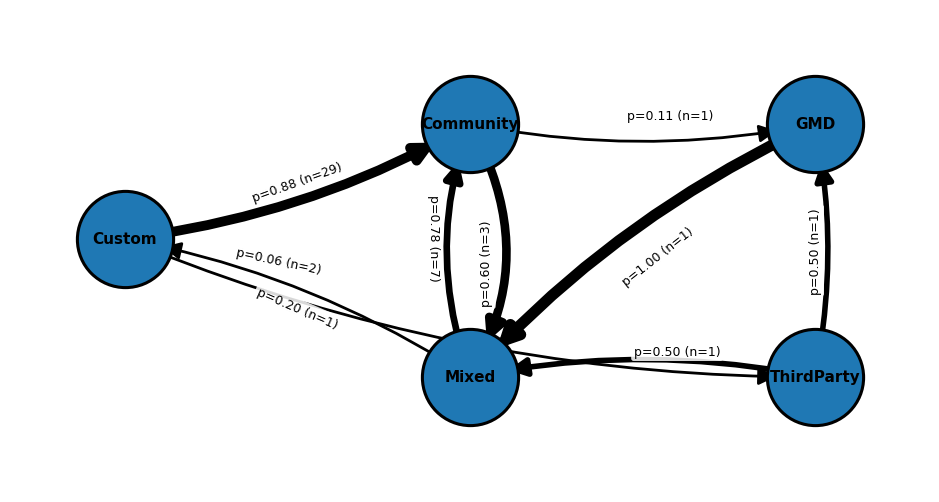

In [27]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import networkx as nx
except ImportError:
    raise SystemExit("Please install networkx (e.g., pip install networkx) to run this script.")

# -----------------------------
# Build graph from computed TOP2
# -----------------------------
G = nx.DiGraph()
G.add_nodes_from(NODES)

for src, edges in TOP2.items():
    for (tgt, p, n) in edges[:2]:
        if p <= 0 or src == tgt:
            continue
        G.add_edge(src, tgt, prob=float(p), count=int(n))

# -----------------------------
# Layout (fixed positions)
# -----------------------------
pos = {
    "Custom": (0.0, 0.0),
    "Community": (1.5, 0.5),
    "Mixed": (1.5, -0.6),
    "GMD": (3.0, 0.5),
    "ThirdParty": (3.0, -0.6),
}
if set(pos.keys()) != set(G.nodes):
    pos = nx.spring_layout(G, seed=7, k=1.0)

# -----------------------------
# Auto curvature for reciprocal pairs (parallel arcs on same side)
# -----------------------------
rad_map = {}
for (u, v) in G.edges:
    if G.has_edge(v, u) and (u, v) not in rad_map and (v, u) not in rad_map:
        rad_map[(u, v)] = -0.28
        rad_map[(v, u)] = -0.18

# -----------------------------
# Figure + padded axes so circles don't clip
# -----------------------------
plt.figure(figsize=(9.5, 5.4))
ax = plt.gca()
ax.set_aspect("equal", adjustable="box")
xs = [xy[0] for xy in pos.values()]
ys = [xy[1] for xy in pos.values()]
PAD_X, PAD_Y = 0.5, 0.5
ax.set_xlim(min(xs) - PAD_X, max(xs) + PAD_X)
ax.set_ylim(min(ys) - PAD_Y, max(ys) + PAD_Y)

# -----------------------------
# Draw edges (first)
# -----------------------------
edge_widths = {e: max(2.0, 8.0 * G[e[0]][e[1]]["prob"]) for e in G.edges}
for (u, v) in G.edges:
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        arrowstyle="-|>",
        arrowsize=26,
        width=edge_widths[(u, v)],
        connectionstyle=f"arc3,rad={rad_map.get((u, v), 0.10)}",
        min_source_margin=20,
        min_target_margin=28,
    )

# Nodes + labels (NO "Community Action" anymore)
nx.draw_networkx_nodes(G, pos, node_size=4800, linewidths=2.2, edgecolors="black")
nx.draw_networkx_labels(G, pos, labels={n: n for n in G.nodes}, font_size=11, font_weight="bold")

# -----------------------------
# Manual edge labels with perpendicular offset + upright text
# -----------------------------
def annotate_edge_label(ax, p0, p1, text, t=0.5, offset_pts=0, **kw):
    x0, y0 = p0
    x1, y1 = p1
    x = (1 - t) * x0 + t * x1
    y = (1 - t) * y0 + t * y1

    P0 = ax.transData.transform([x0, y0])
    P1 = ax.transData.transform([x1, y1])
    vx, vy = P1 - P0

    nx_disp, ny_disp = -vy, vx
    norm = np.hypot(nx_disp, ny_disp)
    if norm == 0:
        dx_pts = dy_pts = 0.0
    else:
        nx_disp /= norm
        ny_disp /= norm
        dx_pts = offset_pts * nx_disp
        dy_pts = offset_pts * ny_disp

    angle = np.degrees(np.arctan2(vy, vx))
    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180

    ax.annotate(
        text,
        xy=(x, y),
        xytext=(dx_pts, dy_pts),
        textcoords="offset points",
        ha="center", va="center",
        rotation=angle,
        rotation_mode="anchor",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
        **kw,
    )

def edge_text(u, v):
    return f"p={G[u][v]['prob']:.2f} (n={G[u][v]['count']})"

# Optional: keep your custom placements (only applied if that edge exists)
placements = {
    ("Community", "Mixed"): {"t": 0.45, "off": -26},
    ("Mixed", "Community"): {"t": 0.45, "off": -12},
    ("Mixed", "ThirdParty"): {"t": 0.40, "off": -22},
    ("ThirdParty", "Mixed"): {"t": 0.40, "off": -18},
    ("Community", "GMD"): {"t": 0.58, "off": +6},
    ("GMD", "Mixed"): {"t": 0.48, "off": +10},
    ("Custom", "ThirdParty"): {"t": 0.22, "off": +6},
}

for (u, v) in G.edges:
    p0, p1 = pos[u], pos[v]
    spec = placements.get((u, v), {"t": 0.50, "off": 0})
    annotate_edge_label(ax, p0, p1, edge_text(u, v), t=spec["t"], offset_pts=spec["off"], fontsize=9)

plt.axis("off")
plt.tight_layout()
plt.show()

# Optional save (rename to RQ2)
# plt.savefig("rq2_state_machine_top2.png", dpi=300, bbox_inches="tight")
